# 08_content_distance.ipynb

> Extract claims from the full corpus and compute pairwise content distances
> Applies the validated extractor to every generated explanation, computes
> fidelity against the supplied evidence, and builds the pairwise distance
> table that the delta analysis in 09 consumes.
> Extraction uses the single LLM extractor validated in 05. The rule-based
> parser trialled earlier was abandoned; see 04 for the reasoning. Because the
> extractor is not perfectly deterministic, its measured self-stability is
> carried through and reported alongside the distances as measurement error.

C:\Users\User\anaconda3\envs\xai-stability\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded credentials from C:\Users\User\Downloads\same-case-different-reasons\project\.env
Corpus: 29,700 generations
Extractor        : gpt-5.6-terra (temperature=None, seed=42)
Rank as primary  : True
Self-stability   : 1.0 (feature overlap across repeat runs)
Extractions pending: 0 of 29,700


loading claims: 100%|██████████| 29700/29700 [01:32<00:00, 322.21it/s]


Claim records: 29,700  {}
Saved: claims_long.parquet (139,012 rows)


,block,domain,model,xai,llm,prompt,temperature,seed,case_id,repeat,feature,direction,rank,in_evidence,evidence_direction,evidence_rank
0,A,credit,LightGBM,SHAP,gpt-5.4-mini,basic,1.0,NaN,5964,3,loan_percent_income,increases,1,True,increases,1.0
1,A,credit,LightGBM,SHAP,gpt-5.4-mini,basic,1.0,NaN,5964,3,person_income,increases,2,True,increases,2.0
2,A,credit,LightGBM,SHAP,gpt-5.4-mini,basic,1.0,NaN,5964,3,person_home_ownership_RENT,increases,3,True,increases,3.0
3,A,credit,LightGBM,SHAP,gpt-5.4-mini,basic,1.0,NaN,5964,3,loan_intent_HOMEIMPROVEMENT,increases,4,True,increases,4.0
4,A,credit,LightGBM,SHAP,gpt-5.4-mini,basic,1.0,NaN,5964,3,person_age,increases,5,True,increases,5.0


...

Saved: tab37_baseline_versus_measurement_error.csv

Repeat baseline against extractor measurement error:


,Block,Observed repeat baseline,Extractor instability,Attributable to generation,Ratio
0,D,0.0486,0.0,0.0486,NaN
1,D0,0.0378,0.0,0.0378,NaN


Saved: tab38_deep_repeatability_by_llm.csv


,block,llm,feature_distance_mean,feature_distance_std,direction_distance_mean,direction_distance_std,rank_distance_mean,rank_distance_std
0,D,gpt-5.4-mini,0.0705,0.1108,0.0094,0.0458,0.0775,0.1792
1,D,gpt-5.6-luna,0.0360,0.1161,0.0015,0.0182,0.0771,0.1681
2,D,gpt-5.6-terra,0.0393,0.0821,0.0286,0.1622,0.0536,0.1683
3,D0,gpt-5.4-mini,0.0604,0.1056,0.0097,0.0501,0.0582,0.1477
4,D0,gpt-5.6-luna,0.0264,0.0939,0.0006,0.0112,0.0648,0.1622
5,D0,gpt-5.6-terra,0.0268,0.0681,0.0252,0.1520,0.0423,0.1335


Saved: fig23_distance_by_contrast.png / fig23_distance_by_contrast.pdf


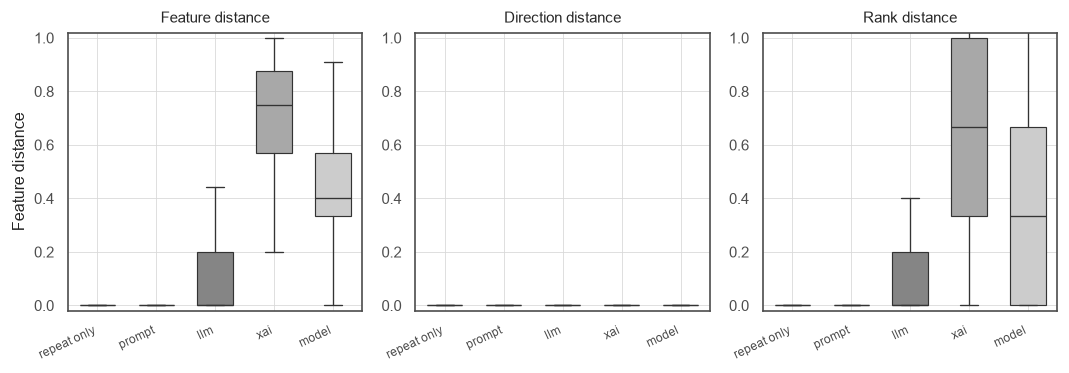

Saved: fig24_repeat_baseline_by_temperature.png / fig24_repeat_baseline_by_temperature.pdf


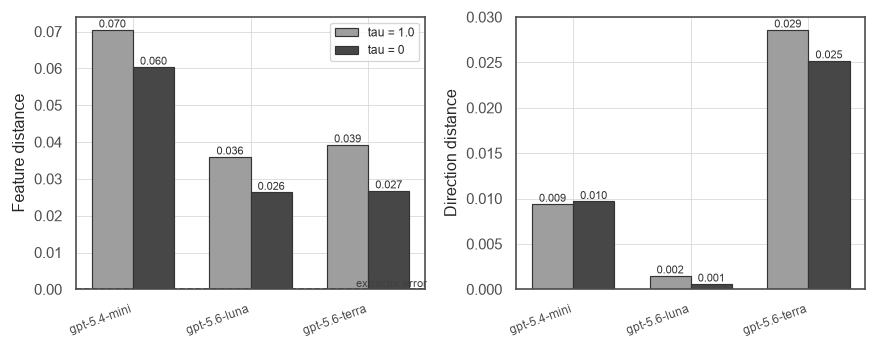

Saved: fig25_fidelity_by_condition.png / fig25_fidelity_by_condition.pdf


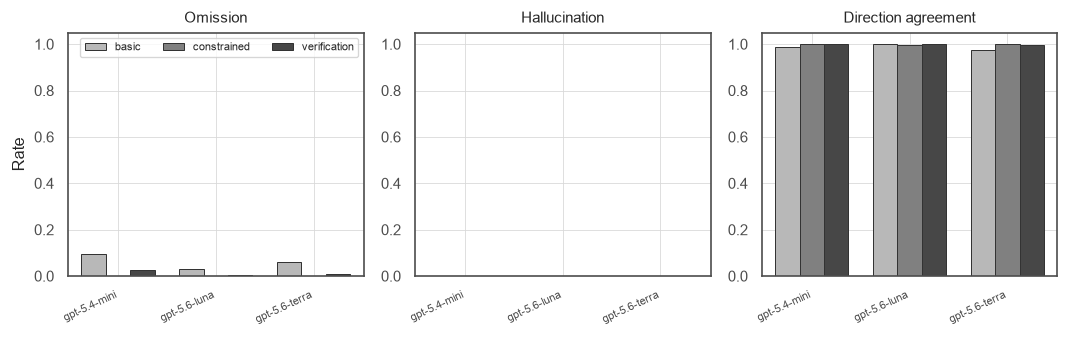

Saved: fig26_baseline_case_heterogeneity.png / fig26_baseline_case_heterogeneity.pdf


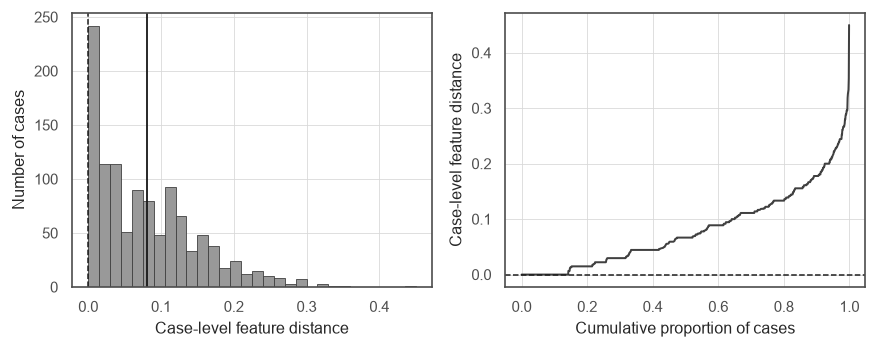

Repeat baseline, case-level feature distance:
  median 0.0667, IQR [0.0222, 0.1222], 90th pct 0.1778
  extractor instability floor: 0.0000
Saved: tab39_direction_resolution_by_condition.csv
Direction resolution spread across conditions: 0.0217


,block,llm,prompt,Direction resolved
0,A,gpt-5.4-mini,basic,0.9908
1,A_prime,gpt-5.4-mini,basic,0.9783
2,B,gpt-5.4-mini,basic,0.9890
3,B,gpt-5.4-mini,constrained,1.0000
4,B,gpt-5.4-mini,verification,0.9986
5,B,gpt-5.6-luna,basic,0.9977
6,B,gpt-5.6-luna,constrained,1.0000
7,B,gpt-5.6-luna,verification,1.0000
8,B,gpt-5.6-terra,basic,0.9823
9,B,gpt-5.6-terra,constrained,1.0000


Saved: distance_manifest.json
Saved: logs/08_run_20260921.json
Analysis-ready datasets:
  claims_long.parquet                    399.3 KB
  fidelity.parquet                        94.8 KB
  content_distances.parquet              874.7 KB
  case_level_distances.parquet            56.7 KB

Outputs:
  results\tables\tab33_fidelity_by_condition.csv
  results\tables\tab34_pairwise_distance_summary.csv
  results\tables\tab35_distance_missingness.csv
  results\tables\tab36_repeat_baseline.csv
  results\tables\tab37_baseline_versus_measurement_error.csv
  results\tables\tab38_deep_repeatability_by_llm.csv
  results\tables\tab39_direction_resolution_by_condition.csv
  results\figures\fig23_distance_by_contrast.pdf
  results\figures\fig23_distance_by_contrast.png
  results\figures\fig24_repeat_baseline_by_temperature.pdf
  results\figures\fig24_repeat_baseline_by_temperature.png
  results\figures\fig25_fidelity_by_condition.pdf
  results\figures\fig25_fidelity_by_condition.png
  results\figures\

In [1]:
# ============================================================================
# 08_content_distance.ipynb
# Extract claims from the full corpus and compute pairwise content distances
# Applies the validated extractor to every generated explanation, computes
# fidelity against the supplied evidence, and builds the pairwise distance
# table that the delta analysis in 09 consumes.
#
# Extraction uses the single LLM extractor validated in 05. The rule-based
# parser trialled earlier was abandoned; see 04 for the reasoning. Because the
# extractor is not perfectly deterministic, its measured self-stability is
# carried through and reported alongside the distances as measurement error.
# ============================================================================


# [Cell 1] Imports and global configuration
import os
import json
import time
import warnings
import threading
from pathlib import Path
from itertools import combinations
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import kendalltau
from openai import OpenAI

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

ROOT = Path("..")
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "results" / "figures"
TAB_DIR = ROOT / "results" / "tables"
LOG_DIR = ROOT / "logs"

for d in [DATA_DIR, FIG_DIR, TAB_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

from dotenv import load_dotenv, find_dotenv

_env = find_dotenv(usecwd=True)
if not _env:
    raise FileNotFoundError("No .env found at the project root")
load_dotenv(_env)
print(f"Loaded credentials from {_env}")


# [Cell 2] Plotting style: grayscale, publication settings
sns.set_theme(style="whitegrid", context="paper")
sns.set_palette(sns.color_palette("gray", n_colors=8))

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linewidth": 0.5,
    "axes.edgecolor": "0.3",
    "axes.labelcolor": "0.15",
    "text.color": "0.15",
    "xtick.color": "0.3",
    "ytick.color": "0.3",
    "image.cmap": "gray",
    "savefig.bbox": "tight",
    "savefig.transparent": False,
})


def save_fig(fig, name):
    """Save a figure as both PNG and PDF at 600 dpi. No caption is added."""
    for ext in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=600, bbox_inches="tight")
    print(f"Saved: {name}.png / {name}.pdf")


def save_table(df, name, index=False):
    """Save a table as CSV under results/tables."""
    df.to_csv(TAB_DIR / f"{name}.csv", index=index, encoding="utf-8-sig")
    print(f"Saved: {name}.csv")


# [Cell 3] Load corpus, configuration and validation outcome
corpus = pd.read_parquet(DATA_DIR / "generation_corpus.parquet")
corpus["evidence"] = corpus["evidence_json"].apply(json.loads)
print(f"Corpus: {len(corpus):,} generations")

with open(DATA_DIR / "extractor_config.json", encoding="utf-8") as f:
    extractor_config = json.load(f)

with open(DATA_DIR / "feature_registry.json", encoding="utf-8") as f:
    feature_registry = json.load(f)

with open(DATA_DIR / "validation_summary.json", encoding="utf-8") as f:
    validation = json.load(f)

if not validation["proceed"]:
    raise RuntimeError(
        "Extraction did not meet the pre-registered gates in 05. "
        "Revise the extractor before analysing the corpus."
    )

RANK_PRIMARY = validation["rank_primary"]
EXTRACTOR_MODEL = extractor_config["extractor_model"]
EXTRACTOR_TEMPERATURE = extractor_config["extractor_temperature"]
EXTRACTOR_SEED = extractor_config.get("extractor_seed", 42)
EXTRACTOR_SYSTEM = extractor_config["extractor_system_prompt"]
CANDIDATE_CAP = extractor_config["candidate_cap"]

print(f"Extractor        : {EXTRACTOR_MODEL} "
      f"(temperature={EXTRACTOR_TEMPERATURE}, seed={EXTRACTOR_SEED})")
print(f"Rank as primary  : {RANK_PRIMARY}")
print(f"Self-stability   : {extractor_config['stability']['Feature Jaccard']} "
      f"(feature overlap across repeat runs)")

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"], timeout=90)


# [Cell 4] The extractor
# Reproduced from the configuration written by 04, so that the pipeline
# validated in 05 is the one applied here. The system prompt is read from the
# config rather than restated, which makes divergence impossible.
def candidates_for(domain, evidence, cap=CANDIDATE_CAP):
    """Supplied drivers first, then other domain features, capped in length."""
    supplied = [d["feature"] for d in evidence]
    others = [f for f in feature_registry[domain]["features"] if f not in supplied]
    return (supplied + others)[:cap]


def normalise_claims(claims):
    """Clean the raw extractor output into a canonical claim list."""
    seen, out = set(), []
    for c in claims:
        feat = c.get("feature")
        if not feat or feat == "OUT_OF_LIST" or feat in seen:
            continue
        seen.add(feat)
        direction = c.get("direction")
        out.append({
            "feature": feat,
            "direction": direction if direction in ("increases", "decreases") else None,
            "rank": c.get("rank"),
        })

    out.sort(key=lambda x: (x["rank"] is None, x["rank"]))
    for i, c in enumerate(out, 1):
        c["rank"] = i
    return out


def extract_claims(text, allowed_features, retries=3):
    """Extract structured claims from a narrative, constrained to a feature list.

    A failed extraction raises rather than returning an empty list. Over 29,700
    generations a silent failure would be indistinguishable from a narrative
    that mentioned nothing, and would enter every downstream metric as a valid
    measurement of perfect divergence.
    """
    user = (
        "ALLOWED FEATURES:\n"
        + "\n".join(f"- {f}" for f in allowed_features)
        + "\n\nEXPLANATION:\n" + text
        + '\n\nReturn JSON: {"claims": [{"feature": ..., "direction": ..., '
          '"rank": ..., "evidence_text": ...}]}'
    )

    kwargs = dict(
        model=EXTRACTOR_MODEL,
        response_format={"type": "json_object"},
        max_completion_tokens=1500,
        seed=EXTRACTOR_SEED,
        messages=[
            {"role": "system", "content": EXTRACTOR_SYSTEM},
            {"role": "user", "content": user},
        ],
    )
    if EXTRACTOR_TEMPERATURE is not None:
        kwargs["temperature"] = EXTRACTOR_TEMPERATURE

    last_error = None
    for attempt in range(retries):
        try:
            resp = client.chat.completions.create(**kwargs)
            return normalise_claims(
                json.loads(resp.choices[0].message.content).get("claims", [])
            )
        except Exception as exc:
            last_error = f"{type(exc).__name__}: {exc}"
            if attempt < retries - 1:
                time.sleep(2 ** attempt)

    raise RuntimeError(f"Extraction failed after {retries} attempts. {last_error}")


# [Cell 5] Batch extraction with caching
# Extraction is cached per generation because it is the second most expensive
# step in the study after generation itself. The cache is also what makes the
# analysis reproducible despite a non-deterministic extractor: once written,
# every downstream result derives from these fixed files.
EXTRACT_DIR = DATA_DIR / "claims_cache"
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

_lock = threading.Lock()
extract_stats = Counter()


def generation_key(row):
    """Stable identifier matching the generation cache addressing scheme."""
    return "_".join([
        row["block"], row["domain"], row["model"], row["xai"], row["llm"],
        row["prompt"], f"{row['temperature']:.1f}", f"seed={row.get('seed')}",
        str(row["case_id"]), str(row["repeat"]),
    ])


def extract_one(row):
    """Extract claims for a single generation, reusing the cache when present."""
    key = generation_key(row)
    path = EXTRACT_DIR / f"{key}.json"
    if path.exists():
        with _lock:
            extract_stats["cached"] += 1
        return

    cands = candidates_for(row["domain"], row["evidence"])
    record = {
        "key": key,
        "block": row["block"], "domain": row["domain"], "model": row["model"],
        "xai": row["xai"], "llm": row["llm"], "prompt": row["prompt"],
        "temperature": float(row["temperature"]),
        "seed": row.get("seed"),
        "case_id": int(row["case_id"]), "repeat": int(row["repeat"]),
        "evidence": row["evidence"],
        "claims": extract_claims(row["explanation"], cands),
    }
    path.write_text(json.dumps(record, ensure_ascii=False, indent=1), encoding="utf-8")
    with _lock:
        extract_stats["extracted"] += 1


records = corpus.to_dict(orient="records")
pending = [r for r in records if not (EXTRACT_DIR / f"{generation_key(r)}.json").exists()]
print(f"Extractions pending: {len(pending):,} of {len(records):,}")

if pending:
    with ThreadPoolExecutor(max_workers=8) as pool:
        futures = [pool.submit(extract_one, r) for r in pending]
        for fut in tqdm(as_completed(futures), total=len(futures), desc="extracting"):
            fut.result()

claim_records = []
for r in tqdm(records, desc="loading claims"):
    path = EXTRACT_DIR / f"{generation_key(r)}.json"
    if path.exists():
        claim_records.append(json.loads(path.read_text(encoding="utf-8")))

print(f"Claim records: {len(claim_records):,}  {dict(extract_stats)}")

empty = sum(1 for r in claim_records if not r["claims"])
if empty:
    print(f"WARNING: {empty:,} generations produced no claims. These are "
          f"excluded from distance computation and must be reported.")


# [Cell 6] Long-format claim table
# The analysis-ready dataset referenced in the research design. Every
# downstream notebook reads this file rather than re-deriving claims.
long_rows = []
for rec in claim_records:
    supplied = {d["feature"]: d for d in rec["evidence"]}
    for c in rec["claims"]:
        ev = supplied.get(c["feature"])
        long_rows.append({
            "block": rec["block"], "domain": rec["domain"],
            "model": rec["model"], "xai": rec["xai"], "llm": rec["llm"],
            "prompt": rec["prompt"], "temperature": rec["temperature"],
            "seed": rec.get("seed"),
            "case_id": rec["case_id"], "repeat": rec["repeat"],
            "feature": c["feature"], "direction": c["direction"],
            "rank": c["rank"],
            "in_evidence": ev is not None,
            "evidence_direction": ev["direction"] if ev else None,
            "evidence_rank": ev["rank"] if ev else None,
        })

claims_long = pd.DataFrame(long_rows)
claims_long.to_parquet(DATA_DIR / "claims_long.parquet", index=False)
print(f"Saved: claims_long.parquet ({len(claims_long):,} rows)")
display(claims_long.head())


# [Cell 7] Fidelity metrics
# Fidelity is measured against what the generator was actually given, not
# against SHAP as ground truth. The reference is therefore the evidence block.
def fidelity_for(rec):
    """Omission, hallucination and direction agreement for one generation."""
    supplied = {d["feature"]: d["direction"] for d in rec["evidence"]}
    claimed = {c["feature"]: c["direction"] for c in rec["claims"]}

    common = set(supplied) & set(claimed)
    resolved = [f for f in common if claimed[f] is not None]

    return {
        "block": rec["block"], "domain": rec["domain"], "model": rec["model"],
        "xai": rec["xai"], "llm": rec["llm"], "prompt": rec["prompt"],
        "temperature": rec["temperature"], "seed": rec.get("seed"),
        "case_id": rec["case_id"], "repeat": rec["repeat"],
        "n_supplied": len(supplied),
        "n_claimed": len(claimed),
        "omission_rate": 1 - len(common) / len(supplied) if supplied else np.nan,
        "hallucination_rate": (
            len(set(claimed) - set(supplied)) / len(claimed) if claimed else np.nan
        ),
        "direction_agreement": (
            float(np.mean([claimed[f] == supplied[f] for f in resolved]))
            if resolved else np.nan
        ),
        "direction_unresolved": (
            1 - len(resolved) / len(common) if common else np.nan
        ),
    }


fidelity = pd.DataFrame([fidelity_for(r) for r in claim_records])
fidelity.to_parquet(DATA_DIR / "fidelity.parquet", index=False)

fidelity_summary = (
    fidelity.groupby(["block", "llm", "prompt"])
    .agg(
        n=("case_id", "size"),
        omission=("omission_rate", "mean"),
        hallucination=("hallucination_rate", "mean"),
        direction_agreement=("direction_agreement", "mean"),
        direction_unresolved=("direction_unresolved", "mean"),
    )
    .round(4)
    .reset_index()
)

save_table(fidelity_summary, "tab33_fidelity_by_condition")
display(fidelity_summary.head(15))


# [Cell 8] Distance functions
# Identical definitions to those used in the power simulation, so that the
# simulated precision applies to the quantities computed here.
def claim_sets(claims):
    """Feature set, direction map and rank map for a claim list."""
    feats, dirs, ranks = set(), {}, {}
    for c in claims:
        f = c.get("feature")
        if not f:
            continue
        feats.add(f)
        dirs[f] = c.get("direction")
        ranks[f] = c.get("rank")
    return feats, dirs, ranks


def feature_distance(claims_a, claims_b):
    """One minus the Jaccard index of the two feature sets."""
    fa, _, _ = claim_sets(claims_a)
    fb, _, _ = claim_sets(claims_b)
    union = fa | fb
    if not union:
        return np.nan
    return 1.0 - len(fa & fb) / len(union)


def direction_distance(claims_a, claims_b):
    """Share of commonly mentioned features whose stated direction differs."""
    fa, da, _ = claim_sets(claims_a)
    fb, db, _ = claim_sets(claims_b)
    common = [f for f in fa & fb if da.get(f) and db.get(f)]
    if not common:
        return np.nan
    return 1.0 - float(np.mean([da[f] == db[f] for f in common]))


def rank_distance(claims_a, claims_b, min_common=3):
    """One minus Kendall's tau over the commonly mentioned features."""
    fa, _, ra = claim_sets(claims_a)
    fb, _, rb = claim_sets(claims_b)
    common = sorted(f for f in fa & fb
                    if ra.get(f) is not None and rb.get(f) is not None)
    if len(common) < min_common:
        return np.nan
    tau = kendalltau([ra[f] for f in common], [rb[f] for f in common]).correlation
    if tau is None or np.isnan(tau):
        return np.nan
    return 1.0 - float(tau)


# [Cell 9] Pair construction
# Pairs are formed only within a case, because content distance is defined as a
# within-case contrast. Each pair is labelled by which single factor differs,
# or "repeat" when nothing differs but the repetition index.
# Temperature is constant throughout; the deterministic condition varies by
# seed instead. D and D-0 are separate blocks and pairs never cross blocks,
# so seed is listed for completeness rather than as an active contrast.
FACTORS = ["model", "xai", "llm", "prompt"]

for f in FACTORS:
    missing = [r for r in claim_records if r.get(f) is None
               or (isinstance(r.get(f), float) and np.isnan(r[f]))]
    if missing:
        raise RuntimeError(
            f"Factor '{f}' is missing in {len(missing):,} claim records. "
            f"Pair labelling requires every factor to be present."
        )

def pair_label(a, b):
    """Identify which factor distinguishes two generations of the same case."""
    differing = [f for f in FACTORS if a[f] != b[f]]
    if not differing:
        return "repeat"
    if len(differing) == 1:
        return f"{differing[0]}_change"
    return "multi_change"


def build_pairs(records):
    """Enumerate all within-case, within-block generation pairs."""
    by_case = defaultdict(list)
    for r in records:
        by_case[(r["block"], r["domain"], r["case_id"])].append(r)

    rows = []
    for (block, domain, case_id), group in tqdm(by_case.items(), desc="pairing"):
        for a, b in combinations(group, 2):
            rows.append({
                "block": block, "domain": domain, "case_id": case_id,
                "contrast": pair_label(a, b),
                "feature_distance": feature_distance(a["claims"], b["claims"]),
                "direction_distance": direction_distance(a["claims"], b["claims"]),
                "rank_distance": rank_distance(a["claims"], b["claims"]),
                "a_model": a["model"], "b_model": b["model"],
                "a_xai": a["xai"], "b_xai": b["xai"],
                "a_llm": a["llm"], "b_llm": b["llm"],
                "a_prompt": a["prompt"], "b_prompt": b["prompt"],
                "a_temp": a["temperature"], "b_temp": b["temperature"],
                "a_seed": a.get("seed"), "b_seed": b.get("seed"),
                "a_repeat": a["repeat"], "b_repeat": b["repeat"],
            })
    return pd.DataFrame(rows)


pairs = build_pairs(claim_records)
print(f"Pairs constructed: {len(pairs):,}")
print(pairs["contrast"].value_counts().to_string())


# [Cell 10] Persist the pair table
pairs.to_parquet(DATA_DIR / "content_distances.parquet", index=False)
print("Saved: content_distances.parquet")

pair_summary = (
    pairs.groupby(["block", "contrast"])
    .agg(
        n_pairs=("case_id", "size"),
        n_cases=("case_id", "nunique"),
        feature_mean=("feature_distance", "mean"),
        feature_sd=("feature_distance", "std"),
        direction_mean=("direction_distance", "mean"),
        direction_sd=("direction_distance", "std"),
        rank_mean=("rank_distance", "mean"),
    )
    .round(4)
    .reset_index()
)

save_table(pair_summary, "tab34_pairwise_distance_summary")
display(pair_summary)


# [Cell 11] Case-level aggregation
# Delta is defined as a case-level contrast, so distances are averaged within
# each case before any comparison across conditions. Aggregating at this level
# also removes the dependence between pairs that share a generation.
METRICS = ["feature_distance", "direction_distance", "rank_distance"]

case_level = (
    pairs.groupby(["block", "domain", "case_id", "contrast"])[METRICS]
    .mean()
    .reset_index()
)
case_level["n_pairs"] = (
    pairs.groupby(["block", "domain", "case_id", "contrast"]).size().values
)

case_level.to_parquet(DATA_DIR / "case_level_distances.parquet", index=False)
print(f"Saved: case_level_distances.parquet ({len(case_level):,} rows)")
display(case_level.head())


# [Cell 12] Missing-value diagnostics
# Direction and rank distances are undefined when two explanations share too
# few features. The rate at which this happens is itself informative: a high
# rate means the explanations diverge so much that direction cannot be
# compared, which is the most extreme form of the instability under study.
missing_rows = []
for (block, contrast), g in pairs.groupby(["block", "contrast"]):
    missing_rows.append({
        "Block": block,
        "Contrast": contrast,
        "N pairs": len(g),
        "Feature undefined": round(g["feature_distance"].isna().mean(), 4),
        "Direction undefined": round(g["direction_distance"].isna().mean(), 4),
        "Rank undefined": round(g["rank_distance"].isna().mean(), 4),
    })

missingness = pd.DataFrame(missing_rows)
save_table(missingness, "tab35_distance_missingness")

max_dir_missing = missingness["Direction undefined"].max()
if max_dir_missing > 0.20:
    print(f"NOTE: direction distance is undefined for up to "
          f"{max_dir_missing:.1%} of pairs in some cells. Explanations sharing "
          f"no common features cannot be compared on direction. Report this "
          f"alongside the distance means rather than treating it as missing data.")

display(missingness)


# [Cell 13] Repeat baseline
# The baseline is the average within-case distance when nothing varies except
# the repetition index. Every delta in 09 is measured against this quantity.
baseline = (
    case_level[case_level["contrast"] == "repeat"]
    .groupby(["block", "domain"])[METRICS]
    .agg(["mean", "std", "count"])
    .round(4)
)
baseline.columns = ["_".join(c) for c in baseline.columns]
baseline = baseline.reset_index()

save_table(baseline, "tab36_repeat_baseline")
print("Repeat baseline by block:")
display(baseline)


# [Cell 14] Baseline against extractor measurement error
# The repeat baseline is what the study attributes to regeneration. Part of it
# is instead the extractor reading the same narrative differently. Comparing
# the two puts a floor under the interpretation: a baseline close to the
# extractor's own instability cannot be attributed to the generator.
extractor_instability = 1.0 - float(
    extractor_config["stability"]["Feature Jaccard"]
)

deep_baseline = baseline[baseline["block"].isin(["D", "D0"])]
comparison_rows = []
for _, r in deep_baseline.iterrows():
    obs = float(r["feature_distance_mean"])
    comparison_rows.append({
        "Block": r["block"],
        "Observed repeat baseline": round(obs, 4),
        "Extractor instability": round(extractor_instability, 4),
        "Attributable to generation": round(max(obs - extractor_instability, 0.0), 4),
        "Ratio": round(obs / extractor_instability, 2) if extractor_instability > 0 else np.nan,
    })

error_floor = pd.DataFrame(comparison_rows)
save_table(error_floor, "tab37_baseline_versus_measurement_error")
print("\nRepeat baseline against extractor measurement error:")
display(error_floor)

if len(error_floor) and error_floor["Ratio"].min() < 2.0:
    print("NOTE: the observed baseline is within twice the extractor's own "
          "instability. The generator's contribution cannot be cleanly "
          "separated from measurement error at this resolution. State this "
          "explicitly rather than reporting the baseline as a generator property.")


# [Cell 15] Deep repeatability by generator and temperature
deep_pairs = pairs[pairs["block"].isin(["D", "D0"])].copy()
deep_pairs["llm"] = deep_pairs["a_llm"]

deep_by_llm = (
    deep_pairs[deep_pairs["contrast"] == "repeat"]
    .groupby(["block", "llm"])[METRICS]
    .agg(["mean", "std"])
    .round(4)
)
deep_by_llm.columns = ["_".join(c) for c in deep_by_llm.columns]
deep_by_llm = deep_by_llm.reset_index()

save_table(deep_by_llm, "tab38_deep_repeatability_by_llm")
display(deep_by_llm)


# [Cell 16] Figure: distance distributions by contrast
fig, axes = plt.subplots(1, 3, figsize=(9.0, 3.2))

contrast_order = ["repeat", "prompt_change", "llm_change", "xai_change", "model_change"]
present = [c for c in contrast_order if c in set(pairs["contrast"])]
shades = ["0.20", "0.38", "0.52", "0.66", "0.80"]
labels = ["Feature distance", "Direction distance", "Rank distance"]

for ax, metric, label in zip(axes, METRICS, labels):
    data = [pairs[pairs["contrast"] == c][metric].dropna() for c in present]
    bp = ax.boxplot(data, widths=0.6, patch_artist=True, showfliers=False)
    for patch, s in zip(bp["boxes"], shades[:len(present)]):
        patch.set_facecolor(s)
        patch.set_edgecolor("0.2")
        patch.set_linewidth(0.7)
    for element in ["whiskers", "caps", "medians"]:
        for item in bp[element]:
            item.set_color("0.2")
            item.set_linewidth(0.8)
    ax.set_xticklabels(
        [c.replace("_change", "").replace("repeat", "repeat only") for c in present],
        fontsize=7, rotation=25, ha="right",
    )
    ax.set_ylabel(label if metric == METRICS[0] else "")
    ax.set_title(label, fontsize=9, color="0.15")
    ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
save_fig(fig, "fig23_distance_by_contrast")
plt.show()


# [Cell 17] Figure: repeat baseline under the two temperature settings
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0))

deep_llms = sorted(deep_by_llm["llm"].unique())
x = np.arange(len(deep_llms))
width = 0.35

for ax, metric, label in zip(
    axes, ["feature_distance_mean", "direction_distance_mean"],
    ["Feature distance", "Direction distance"],
):
    for i, (block, tag, shade) in enumerate(
        [("D", "tau = 1.0", "0.62"), ("D0", "tau = 0", "0.28")]
    ):
        vals = [
            deep_by_llm[
                (deep_by_llm["block"] == block) & (deep_by_llm["llm"] == m)
            ][metric].mean()
            for m in deep_llms
        ]
        ax.bar(x + (i - 0.5) * width, vals, width,
               color=shade, edgecolor="0.2", linewidth=0.7, label=tag)
        for xi, v in zip(x + (i - 0.5) * width, vals):
            if not np.isnan(v):
                ax.text(xi, v, f"{v:.3f}", ha="center", va="bottom",
                        fontsize=6.5, color="0.2")

    # Extractor instability as the floor below which nothing is interpretable
    if metric.startswith("feature"):
        ax.axhline(extractor_instability, color="0.1",
                   linestyle="--", linewidth=0.9)
        ax.text(len(deep_llms) - 0.5, extractor_instability,
                " extractor error", fontsize=6.5, color="0.25",
                va="bottom", ha="right")

    ax.set_xticks(x)
    ax.set_xticklabels(deep_llms, fontsize=7, rotation=20, ha="right")
    ax.set_ylabel(label)
    if metric.startswith("feature"):
        ax.legend(fontsize=7, frameon=True, loc="upper right")

plt.tight_layout()
save_fig(fig, "fig24_repeat_baseline_by_temperature")
plt.show()


# [Cell 18] Figure: fidelity by generator and prompt
fig, axes = plt.subplots(1, 3, figsize=(9.0, 2.9))

fid_metrics = ["omission_rate", "hallucination_rate", "direction_agreement"]
fid_labels = ["Omission", "Hallucination", "Direction agreement"]
llms = sorted(fidelity["llm"].unique())
prompts = sorted(fidelity["prompt"].unique())
pshades = ["0.72", "0.50", "0.28"]

for ax, metric, label in zip(axes, fid_metrics, fid_labels):
    x = np.arange(len(llms))
    width = 0.25
    for i, p in enumerate(prompts):
        vals = [
            fidelity[(fidelity["llm"] == m) & (fidelity["prompt"] == p)][metric].mean()
            for m in llms
        ]
        ax.bar(x + (i - 1) * width, vals, width,
               color=pshades[i % 3], edgecolor="0.2", linewidth=0.6, label=p)
    ax.set_xticks(x)
    ax.set_xticklabels(llms, fontsize=6.5, rotation=25, ha="right")
    ax.set_title(label, fontsize=9, color="0.15")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Rate" if metric == fid_metrics[0] else "")
    if metric == fid_metrics[0]:
        ax.legend(fontsize=6.5, frameon=True, ncol=3, loc="upper right")

plt.tight_layout()
save_fig(fig, "fig25_fidelity_by_condition")
plt.show()


# [Cell 19] Figure: case-level heterogeneity in the repeat baseline
# A moderate average baseline can conceal a subset of cases whose explanations
# are highly unstable even under identical conditions.
repeat_cases = case_level[case_level["contrast"] == "repeat"]

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0))

axes[0].hist(
    repeat_cases["feature_distance"].dropna(), bins=30,
    color="0.6", edgecolor="0.25", linewidth=0.5,
)
axes[0].axvline(repeat_cases["feature_distance"].mean(),
                color="0.1", linestyle="-", linewidth=1.1)
axes[0].axvline(extractor_instability, color="0.1",
                linestyle="--", linewidth=0.9)
axes[0].set_xlabel("Case-level feature distance")
axes[0].set_ylabel("Number of cases")

sorted_vals = np.sort(repeat_cases["feature_distance"].dropna().values)
axes[1].plot(np.arange(len(sorted_vals)) / len(sorted_vals), sorted_vals,
             color="0.25", linewidth=1.2)
axes[1].axhline(extractor_instability, color="0.1",
                linestyle="--", linewidth=0.9)
axes[1].set_xlabel("Cumulative proportion of cases")
axes[1].set_ylabel("Case-level feature distance")

plt.tight_layout()
save_fig(fig, "fig26_baseline_case_heterogeneity")
plt.show()

q = repeat_cases["feature_distance"].quantile([0.25, 0.5, 0.75, 0.9]).round(4)
print("Repeat baseline, case-level feature distance:")
print(f"  median {q[0.5]}, IQR [{q[0.25]}, {q[0.75]}], 90th pct {q[0.9]}")
print(f"  extractor instability floor: {extractor_instability:.4f}")


# [Cell 20] Sensitivity: unresolved directions by condition
# Claims whose direction the extractor could not resolve are excluded from the
# direction distance by construction. This check confirms that their frequency
# does not vary systematically across conditions, which would otherwise박ㅇㄻㄴㅇㄹ
# confound the between-condition comparison in 09.
claims_long["direction_resolved"] = claims_long["direction"].notna()

resolution = (
    claims_long.groupby(["block", "llm", "prompt"])["direction_resolved"]
    .mean()
    .round(4)
    .reset_index()
    .rename(columns={"direction_resolved": "Direction resolved"})
)

save_table(resolution, "tab39_direction_resolution_by_condition")

spread = resolution["Direction resolved"].max() - resolution["Direction resolved"].min()
print(f"Direction resolution spread across conditions: {spread:.4f}")
if spread > 0.10:
    print("NOTE: unresolved directions are unevenly distributed across "
          "conditions. Report as a limitation on the direction metric.")

display(resolution.head(10))


# [Cell 21] Persist the distance manifest
manifest = {
    "notebook": "08_content_distance",
    "timestamp": pd.Timestamp.now().isoformat(),
    "extractor": {
        "approach": extractor_config["approach"],
        "model": EXTRACTOR_MODEL,
        "temperature": EXTRACTOR_TEMPERATURE,
        "self_stability": extractor_config["stability"],
        "validation": validation["extractor"],
    },
    "n_generations": int(len(corpus)),
    "n_claim_records": int(len(claim_records)),
    "n_empty_extractions": int(empty),
    "n_claims": int(len(claims_long)),
    "n_pairs": int(len(pairs)),
    "n_case_level_rows": int(len(case_level)),
    "rank_primary": RANK_PRIMARY,
    "contrast_counts": pairs["contrast"].value_counts().to_dict(),
    "repeat_baseline": baseline.to_dict(orient="records"),
    "baseline_versus_measurement_error": error_floor.to_dict(orient="records"),
    "fidelity_overall": {
        "omission": round(float(fidelity["omission_rate"].mean()), 4),
        "hallucination": round(float(fidelity["hallucination_rate"].mean()), 4),
        "direction_agreement": round(float(fidelity["direction_agreement"].mean()), 4),
    },
    "missingness": missingness.to_dict(orient="records"),
}

with open(DATA_DIR / "distance_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2, default=str)
print("Saved: distance_manifest.json")

stamp = pd.Timestamp.now().strftime("%Y%m%d")
with open(LOG_DIR / f"08_run_{stamp}.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2, default=str)
print(f"Saved: logs/08_run_{stamp}.json")


# [Cell 22] Verification and handover notes
print("Analysis-ready datasets:")
for name in ["claims_long.parquet", "fidelity.parquet",
             "content_distances.parquet", "case_level_distances.parquet"]:
    p = DATA_DIR / name
    print(f"  {p.name:<34} {p.stat().st_size / 1024:>9.1f} KB")

print("\nOutputs:")
for p in sorted(TAB_DIR.glob("tab3[3-9]*")) + sorted(FIG_DIR.glob("fig2[3-6]*")):
    print(f"  {p.relative_to(ROOT)}")

print(f"""
Key quantities
--------------
Claims extracted        {len(claims_long):,}
Pairs constructed       {len(pairs):,}
Repeat-only pairs       {int((pairs['contrast'] == 'repeat').sum()):,}
Direction agreement     {fidelity['direction_agreement'].mean():.4f}
Extractor error floor   {extractor_instability:.4f}

The repeat baseline in tab36 is the reference against which every delta in 09
is measured. Two cautions carry forward into the write-up:

  - Part of the baseline is the extractor reading the same narrative
    differently, not the generator producing different content. tab37
    quantifies that floor.
  - If the observed baseline departs substantially from the pilot scenario
    used in 06, re-run the power simulation with the observed values before
    interpreting the delta estimates.

Next step: 09_delta_analysis.ipynb
""")